# **Step 1: Loading the data & Relational schema integration**

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
print('loading CSV files...')
transactions = pd.read_csv('../Data/transactions_data.csv')
cards = pd.read_csv('../Data/cards_data.csv')
users = pd.read_csv('../Data/users_data.csv')

loading CSV files...


In [4]:
cards.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [5]:
cards.info()

<class 'pandas.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id                     6146 non-null   int64
 1   client_id              6146 non-null   int64
 2   card_brand             6146 non-null   str  
 3   card_type              6146 non-null   str  
 4   card_number            6146 non-null   int64
 5   expires                6146 non-null   str  
 6   cvv                    6146 non-null   int64
 7   has_chip               6146 non-null   str  
 8   num_cards_issued       6146 non-null   int64
 9   credit_limit           6146 non-null   str  
 10  acct_open_date         6146 non-null   str  
 11  year_pin_last_changed  6146 non-null   int64
 12  card_on_dark_web       6146 non-null   str  
dtypes: int64(6), str(7)
memory usage: 851.5 KB


In [6]:
with open('../Data/mcc_codes.json') as f:
    mcc_dict = json.load(f)

with open('../Data/train_fraud_labels.json') as f:
    fraud_labels = json.load(f)

print('Finished Loading JSON files')

Finished Loading JSON files


In [7]:
labels_dict = fraud_labels.get('target', fraud_labels)

In [8]:
fraud_df = pd.DataFrame(list(labels_dict.items()), columns=['id', 'is_fraud'])

fraud_df['id'] = pd.to_numeric(fraud_df['id'], errors='coerce')
fraud_df['is_fraud'] = fraud_df['is_fraud'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0, True: 1, False: 0})

print("Shape:", fraud_df.shape)
print(fraud_df.head())

Shape: (8914963, 2)
         id  is_fraud
0  10649266         0
1  23410063         0
2   9316588         0
3  12478022         0
4   9558530         0


In [9]:
# 1. Merge Transactions with Fraud Labels
df = transactions.merge(fraud_df, on='id', how='inner')

# 2. Merge with Cards Data
# Match transactions(client_id, card_id) with cards(client_id, id)
df = df.merge(
    cards, 
    left_on=['client_id', 'card_id'], 
    right_on=['client_id', 'id'], 
    how='left', 
    suffixes=('', '_card')
)

# 3. Merge with Users Data
# Match transactions(client_id) with users(id)
df = df.merge(
    users, 
    left_on='client_id', 
    right_on='id', 
    how='left', 
    suffixes=('', '_user')
)

# 4. Clean duplicate ID columns created during joins
df = df.drop(columns=['id_card', 'id_user'], errors='ignore')

currency_cols = ['amount', 'credit_limit', 'per_capita_income', 'yearly_income', 'total_debt']
for col in currency_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse timestamp
df['date'] = pd.to_datetime(df['date'])

print(f"\nDataset Ingestion & Merge Complete!")
print(f"Total Rows & Columns: {df.shape}")
df.head(3)


Dataset Ingestion & Merge Complete!
Total Rows & Columns: (8914963, 37)


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.80,-100.76,23679,48277,110153,740,4
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,6,Male,604 Pine Street,40.80,-91.12,18076,36853,112139,834,5
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,...,4,Male,2379 Forest Lane,33.18,-117.29,16894,34449,36540,686,3


# **Step 2: Key Diagnostic Checks (Target Imbalance & Data Quality)**

## **Target Imbalance Check**

Our initial check shows that fraud makes up only 0.15% of all transactions (1 in 668). This reveals that standard accuracy is useless, since guessing "not fraud" every time still gets 99.85%. Based on this insight, we can instead use PR-AUC (Precision-Recall AUC) to measure model performance later. This helps us focus on catching real fraud without constantly annoying good customers with false alarms.

In [10]:
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print(f"Total Transactions: {len(df):,}")
print(f"Legitimate (0): {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraudulent (1): {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")

# Imbalance Ratio
imbalance_ratio = fraud_counts[0] / fraud_counts[1]
print(f"Class Imbalance Ratio: ~{imbalance_ratio:.1f} : 1")

Total Transactions: 8,914,963
Legitimate (0): 8,901,631 (99.85%)
Fraudulent (1): 13,332 (0.15%)
Class Imbalance Ratio: ~667.7 : 1


## **Missing Values & High Cardinality Audit**
1. Errors (98.4%) = This shows that 98% of the data is error free, that means that the rest 1.6% of data has the actual error like (Bad CVV, insufficient funds)
2. Merchant State (11.75%) & Zip (12.42%) = This percentages indicates transaction that ~12% of the data is done online/internationally.

In [11]:
null_summary = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': null_summary, 'Percentage (%)': null_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                Missing Count  Percentage (%)
merchant_state        1047865       11.754003
zip                   1107377       12.421555
errors                8773196       98.409786


In [12]:
print("=" * 65)
print("1. BREAKDOWN OF ERROR REASONS & THEIR FRAUD RATES")
print("=" * 65)
error_breakdown = df.groupby(df['errors'].fillna('No Error (Clean)')).agg(
    total_count=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum'),
    fraud_rate_pct=('is_fraud', lambda x: x.mean() * 100)
).reset_index()

# Calculate percentage of all transactions each error represents
error_breakdown['pct_of_all_tx'] = (error_breakdown['total_count'] / len(df)) * 100

# Sort by highest transaction volume
error_breakdown = error_breakdown.sort_values('total_count', ascending=False)
print(error_breakdown.to_string(index=False))

1. BREAKDOWN OF ERROR REASONS & THEIR FRAUD RATES
                                             errors  total_count  fraud_count  fraud_rate_pct  pct_of_all_tx
                                   No Error (Clean)      8773196        12763        0.145477      98.409786
                               Insufficient Balance        87686          169        0.192733       0.983582
                                            Bad PIN        21488          112        0.521221       0.241033
                                   Technical Glitch        17776           31        0.174392       0.199395
                                    Bad Card Number         5235           59        1.127030       0.058722
                                            Bad CVV         4091          139        3.397702       0.045889
                                     Bad Expiration         4086           54        1.321586       0.045833
                                        Bad Zipcode          767            0 

In [13]:
print("\n" + "=" * 65)
print("2. CROSS-TABULATION: 'use_chip' VS. 'merchant_state is NULL'")
print("=" * 65)
cross_tab = pd.crosstab(
    df['use_chip'], 
    df['merchant_state'].isnull(), 
    rownames=['Transaction Method (use_chip)'], 
    colnames=['Is State Missing (Online)?'],
    margins=True
)

# Convert to percentages to see the exact overlap
cross_tab_pct = pd.crosstab(
    df['use_chip'], 
    df['merchant_state'].isnull(), 
    rownames=['Transaction Method (use_chip)'], 
    colnames=['Is State Missing (Online)?'],
    normalize='all'
) * 100

print("Counts:")
print(cross_tab)
print("\nPercentages (% of total dataset):")
print(cross_tab_pct.round(2))


2. CROSS-TABULATION: 'use_chip' VS. 'merchant_state is NULL'
Counts:
Is State Missing (Online)?       False     True      All
Transaction Method (use_chip)                           
Chip Transaction               3198886     3890  3202776
Online Transaction                   0  1043975  1043975
Swipe Transaction              4668212        0  4668212
All                            7867098  1047865  8914963

Percentages (% of total dataset):
Is State Missing (Online)?     False  True 
Transaction Method (use_chip)              
Chip Transaction               35.88   0.04
Online Transaction              0.00  11.71
Swipe Transaction              52.36   0.00


# **Step 3: Core EDA Evaluations**

## **Spending Distributions**
Fraudulent transactions tend to have higher amounts (median ~$75) than legitimate ones (median ~$32). We also see small spikes in very tiny charges under $1.00, which points to fraudsters testing stolen cards. This confirms that transaction amount is a strong feature to help our model detect fraud.

C:\Users\edwar\AppData\Local\Temp\ipykernel_20652\632618317.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\edwar\AppData\Local\Temp\ipykernel_20652\632618317.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])


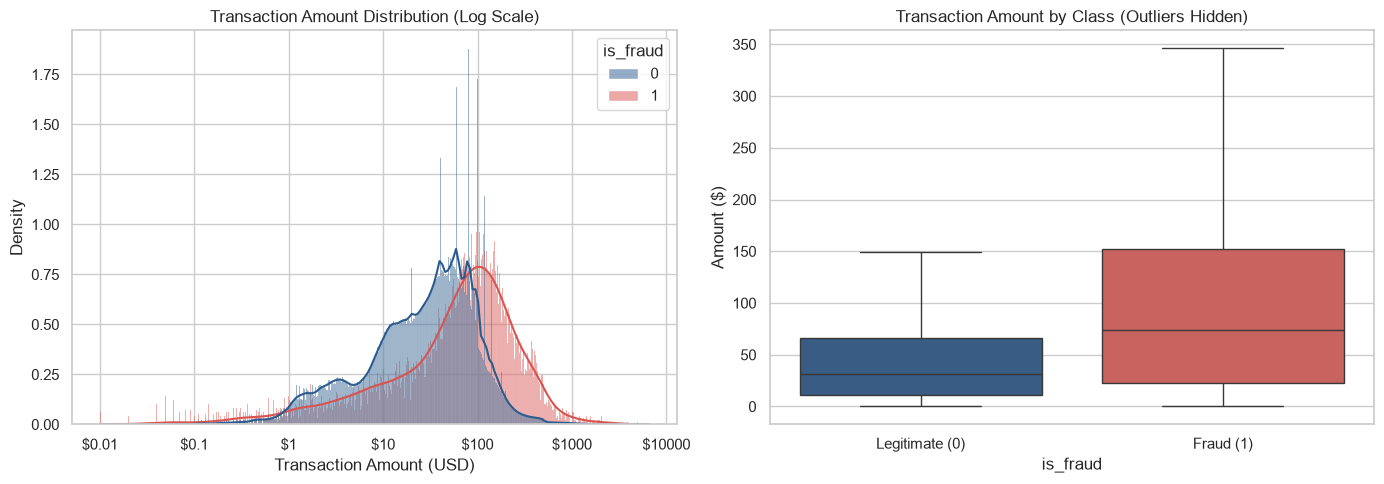

In [14]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data = df[df['amount'] > 0]

# Left: Log Distribution with CLEAN DOLLAR LABELS
sns.histplot(
    data=plot_data, 
    x='amount', 
    hue='is_fraud', 
    kde=True, 
    log_scale=True,
    palette=['#2b5c8f', '#d9534f'], 
    stat="density", 
    common_norm=False, 
    ax=axes[0]
)

# Format the x-axis tick labels into readable dollars ($0.01, $1, $10, $100, $1k, $10k)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"${y:g}"))
axes[0].set_title("Transaction Amount Distribution (Log Scale)")
axes[0].set_xlabel("Transaction Amount (USD)")

# Right: Boxplot
sns.boxplot(
    data=plot_data, 
    x='is_fraud', 
    y='amount', 
    palette=['#2b5c8f', '#d9534f'], 
    showfliers=False, 
    ax=axes[1]
)
axes[1].set_title("Transaction Amount by Class (Outliers Hidden)")
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1].set_ylabel("Amount ($)")

plt.tight_layout()
plt.show()

In [15]:
non_positive_count = (df['amount'] <= 0).sum()
print(f"Transactions with amount <= 0: {non_positive_count:,}")

Transactions with amount <= 0: 449,972


In [16]:
# Create a category to break down <= 0 amounts
conditions = [
    df['amount'] < 0,
    df['amount'] == 0,
    df['amount'] > 0
]
choices = ['Negative (Refunds/Reversals)', 'Zero ($0 Auth Pings)', 'Positive (> $0)']
df['amount_category'] = np.select(conditions, choices, default='Unknown')

# Check transaction volume and fraud rate for each
amount_breakdown = df.groupby('amount_category').agg(
    total_tx=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum'),
    fraud_rate_pct=('is_fraud', lambda x: x.mean() * 100)
).reset_index()

print("=== AMOUNT CATEGORY VS FRAUD RATE ===")
print(amount_breakdown)

=== AMOUNT CATEGORY VS FRAUD RATE ===
                amount_category  total_tx  fraud_count  fraud_rate_pct
0  Negative (Refunds/Reversals)    442779          490        0.110665
1               Positive (> $0)   8464991        12837        0.151648
2          Zero ($0 Auth Pings)      7193            5        0.069512


- Positive charges ($> \$0$) drive over $96\%$ of all fraud volume ($12,837$ cases, $0.152\%$ rate).
- Negative transactions ($< \$0$) account for ~443k rows and include $490$ fraud cases ($0.111\%$ rate), indicating refund/chargeback-related fraud.
- Zero-dollar pings ($= \$0$) capture pre-authorization card validity tests.

## **Temporal Spending Patterns**
Fraud probability spikes at around 10-11 AM. This is a primary peak during business hours where transaction fraud is hidden between real transaction. The secondary peak is at around 3-4 AM, reflecting off-hours attack that take advantages of time where people are often sleeping. At 8 PM till 2 AM, fraud transaction is near 0% .

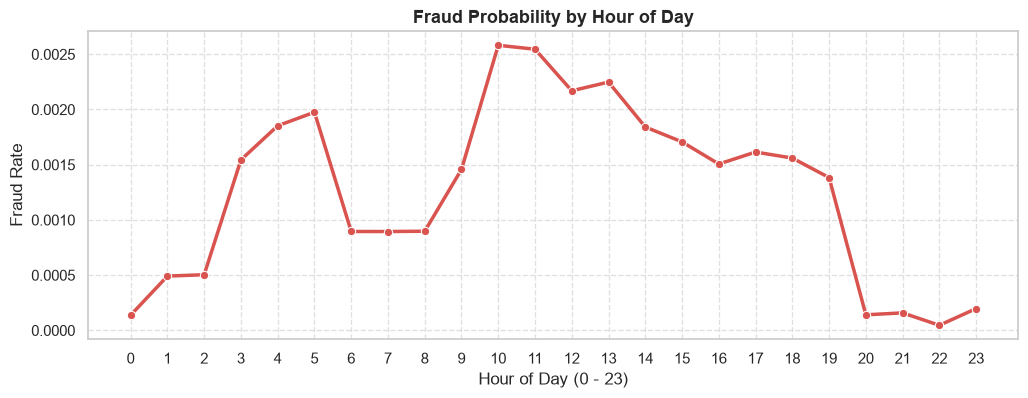

In [ ]:
df['hour'] = df['date'].dt.hour
df['day_name'] = df['date'].dt.day_name()

# Fraud Rate by Hour of Day
hourly_fraud = df.groupby('hour')['is_fraud'].agg(['count', 'mean']).reset_index()

plt.figure(figsize=(12, 4))
sns.lineplot(data=hourly_fraud, x='hour', y='mean', marker='o', color='#d9534f', linewidth=2.5)
plt.title("Fraud Probability by Hour of Day", fontsize=13, fontweight='bold')
plt.xlabel("Hour of Day (0 - 23)")
plt.ylabel("Fraud Rate")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Chip Usage / Transaction Type Breakdown**

C:\Users\edwar\AppData\Local\Temp\ipykernel_20652\1162700575.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chip_fraud, x='use_chip', y='fraud_rate', palette='viridis')


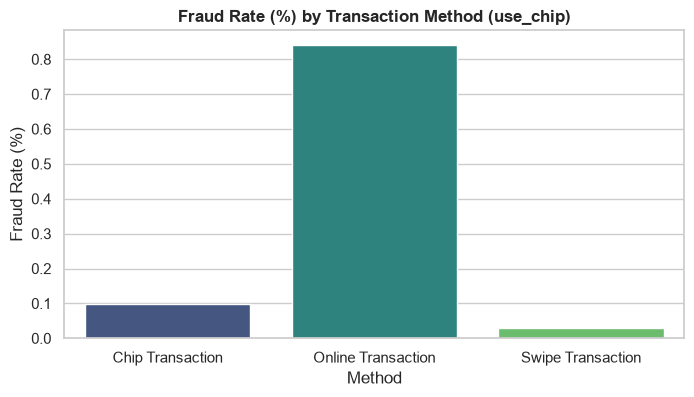

In [18]:
if 'use_chip' in df.columns:
    chip_fraud = df.groupby('use_chip')['is_fraud'].agg(
        total_tx='count',
        fraud_tx='sum',
        fraud_rate=lambda x: x.mean() * 100
    ).reset_index()

    plt.figure(figsize=(8, 4))
    sns.barplot(data=chip_fraud, x='use_chip', y='fraud_rate', palette='viridis')
    plt.title("Fraud Rate (%) by Transaction Method (use_chip)", fontweight='bold')
    plt.xlabel("Method")
    plt.ylabel("Fraud Rate (%)")
    plt.show()

Online transactions carry the highest fraud risk by a wide margin (~0.84%), showing a fraud rate nearly 9× higher than chip transactions (~0.10%) and over 25× higher than swipe transactions (~0.03%). This highlights Card-Not-Present (CNP) channels as the primary vulnerability vector, making transaction method an essential categorical feature for model risk scoring.

## **Top High-Risk Merchant Categories (MCC)**
Fraud is heavily concentrated in high-value, luxury, and easily resellable merchandise. Cruise Lines leads with a ~60% fraud rate, followed by Musical Instrument Stores (~37%), Electronics / Computer Equipment (~8–11%), and Precious Stones. Compared to the overall 0.15% baseline, these categories present extreme vulnerability. To capture this without high-cardinality label bloat, we will engineer target-encoded MCC risk scores and high-risk category indicators for model training.

C:\Users\edwar\AppData\Local\Temp\ipykernel_20652\3265926411.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mcc_stats, x='fraud_rate', y='mcc_desc', palette='Reds_r')


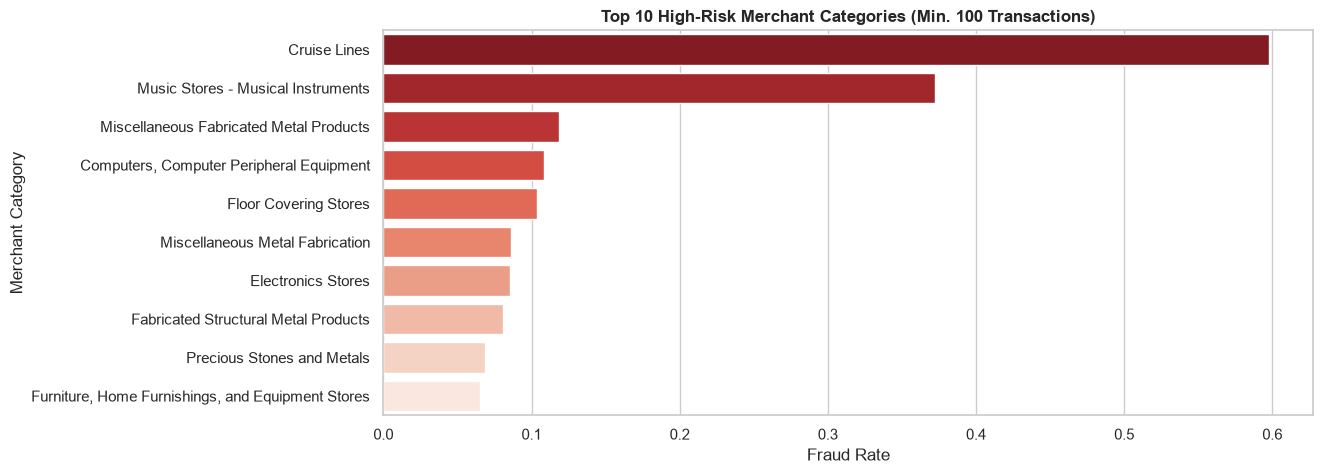

In [19]:
# Map MCC integer code to text description from JSON
df['mcc_desc'] = df['mcc'].astype(str).map(mcc_dict).fillna("Unknown Category")

# Find top categories with minimum volume threshold (e.g., > 100 transactions)
mcc_stats = df.groupby('mcc_desc')['is_fraud'].agg(
    total_tx='count',
    fraud_rate='mean'
).query('total_tx >= 100').sort_values('fraud_rate', ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=mcc_stats, x='fraud_rate', y='mcc_desc', palette='Reds_r')
plt.title("Top 10 High-Risk Merchant Categories (Min. 100 Transactions)", fontweight='bold')
plt.xlabel("Fraud Rate")
plt.ylabel("Merchant Category")
plt.show()